# 04 · Turnout Model and 2021 Backtest

Notebook 4 of 6 · **Eastern Cape Municipal Electoral Dynamics**

**Question.** *Using only information available before an election, how accurately can each municipality's turnout be predicted, and which part of turnout is predictable at all?*

| | |
|---|---|
| **Inputs** | `data/processed/panels/phase3/master_panel_2000_2021.csv` |
| **Outputs** | `data/processed/models/phase4/*.csv`, figures in `reports/figures/phase4/` |
| **Code** | `src/models/turnout.py`, `src/models/evaluation.py` |

**At a glance**
- Turnout is split into a **provincial level** and each municipality's **relative position**. The two behave very differently.
- Models are compared with **rolling-origin validation**: validated on 2011 and 2016, with the method chosen *before* looking at 2021, then tested once on 2021.
- **Relative persistence** (each municipality keeps its previous position relative to the province) wins validation and also has the lowest 2021 test error: **2.08 points** for the relative position, with r = 0.77 between predicted and actual.
- No model could foresee the **8.2-point province-wide fall in 2021**, so full-turnout error in 2021 is about 8.2 points for every method. The provincial level is therefore treated as a stated **scenario assumption** in Notebook 06 rather than a forecast.
- Ridge regression and random forests do not beat persistence, and adding Census 2011 information does not improve the relative forecast.

In [1]:
# Setup: locate the repository root so this notebook runs from any working folder,
# then import the shared project code in src/ (the single source of truth for logic).
import sys, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as C
from src.visualization.style import apply_style, subtitle, save, choropleth, map_colorbar, source_note, SEQ_CMAP, DIV_CMAP

apply_style()
C.ensure_dirs()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)
print("Repository root:", ROOT.name)

Repository root: Dirisa_TeamQualification


In [2]:
from src.models import turnout as T
master = pd.read_csv(C.DIRS["phase3"] / "master_panel_2000_2021.csv")
frame = T.modelling_frame(master)
print("Modelling rows (targets 2006-2021 with a previous election):", len(frame))
display(frame.groupby("Year").size().rename("Municipalities").to_frame().T)

Modelling rows (targets 2006-2021 with a previous election): 131


Year,2006,2011,2016,2021
Municipalities,32,33,33,33


## 1. Two components of turnout

$$\text{Turnout}_{m,t} = \text{Level}_t + \text{Relative}_{m,t}$$

*Level* is the unweighted mean of municipal turnout in election *t*; *Relative* is how many points municipality *m* sits above or below it.

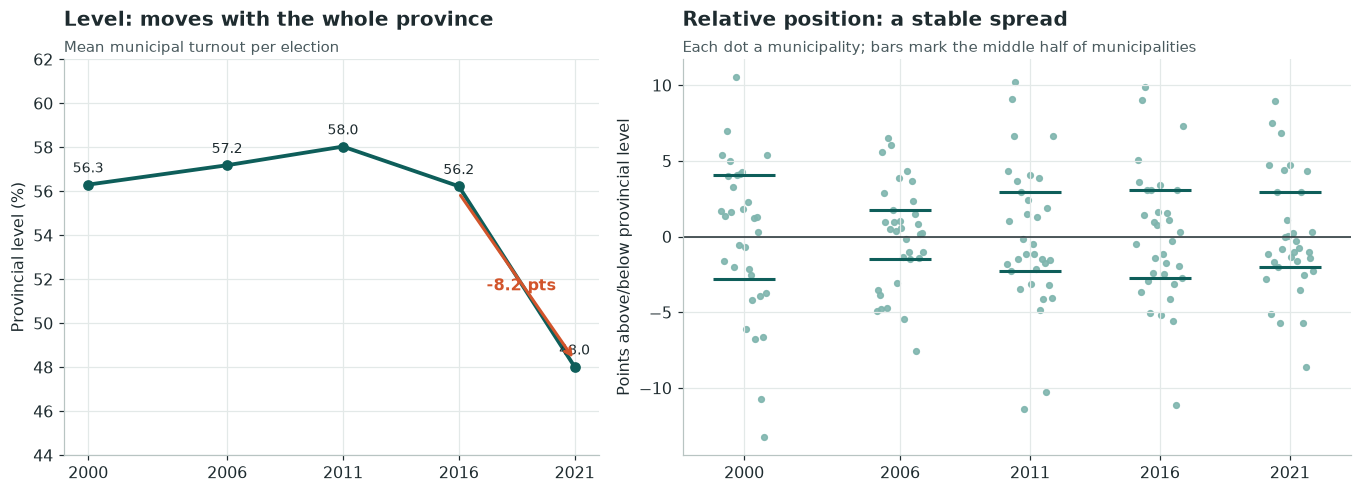

In [3]:
lv = master.groupby("Year")["ProvincialLevel_%"].first()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
ax.plot(lv.index, lv.values, marker="o", color=C.TEAL, lw=2.5)
for x_, y_ in lv.items():
    ax.annotate(f"{y_:.1f}", (x_, y_), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax.annotate("", xy=(2021, lv[2021] + .3), xytext=(2016, lv[2016] - .3),
            arrowprops=dict(arrowstyle="->", color=C.ALOE, lw=2))
ax.text(2017.2, 51.5, f"{lv[2021]-lv[2016]:+.1f} pts", color=C.ALOE, fontweight="bold")
ax.set_xticks(lv.index); ax.set_ylim(44, 62); ax.set_ylabel("Provincial level (%)")
ax.set_title("Level: moves with the whole province", pad=22)
subtitle(ax, "Mean municipal turnout per election")
ax = axes[1]
for i, y in enumerate(C.ELECTION_YEARS):
    v = master.loc[master["Year"] == y, "RelativeTurnout_pts"]
    ax.scatter(np.full(len(v), y) + np.linspace(-.9, .9, len(v)), v, s=14, color=C.TEAL_LIGHT, alpha=.9)
    ax.hlines([v.quantile(.25), v.quantile(.75)], y - 1.2, y + 1.2, color=C.TEAL, lw=2)
ax.axhline(0, color=C.INK, lw=1); ax.set_xticks(C.ELECTION_YEARS)
ax.set_ylabel("Points above/below provincial level"); ax.set_title("Relative position: a stable spread", pad=22)
subtitle(ax, "Each dot a municipality; bars mark the middle half of municipalities")
fig.tight_layout(); save(fig, "turnout_decomposition", "phase4"); plt.show()

The level shifted by −8.2 points in 2021, while the spread of relative positions stayed about the same. A model built from municipal history can hope to predict the right-hand panel; the left-hand panel is driven by province- and nation-wide conditions.

## 2. Validation design: rolling origin, no peeking

Rows are never split at random, because that would let a model learn from later elections when predicting earlier ones.

,Fold,Role,Trained on target elections,Predicts
0,2011,Validation,2006,2011
1,2016,Validation,"2006, 2011",2016
2,2021,Final test,"2006, 2011, 2016",2021


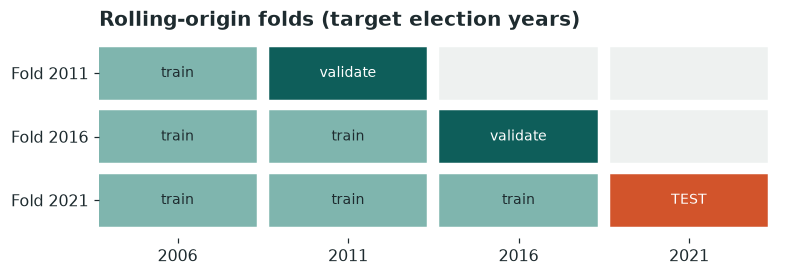

In [4]:
design = pd.DataFrame([{"Fold": y, "Role": "Final test" if y == T.TEST_FOLD else "Validation",
                        "Trained on target elections": ", ".join(map(str, tr)),
                        "Predicts": y} for y, tr in T.FOLDS.items()])
display(design)

fig, ax = plt.subplots(figsize=(8, 2.4))
years = [2006, 2011, 2016, 2021]
for i, (y, tr) in enumerate(T.FOLDS.items()):
    for j, yy in enumerate(years):
        col = C.TEAL_LIGHT if yy in tr else (C.ALOE if yy == y and y == T.TEST_FOLD else (C.TEAL if yy == y else "#EEF1F0"))
        ax.add_patch(plt.Rectangle((j, -i), .92, .8, color=col))
        txt = "train" if yy in tr else ("TEST" if yy == y and y == T.TEST_FOLD else ("validate" if yy == y else ""))
        ax.text(j + .46, -i + .4, txt, ha="center", va="center", fontsize=9, color="white" if txt in ("TEST", "validate") else C.INK)
ax.set_xlim(0, 4); ax.set_ylim(-2.2, 1); ax.set_xticks([j + .46 for j in range(4)]); ax.set_xticklabels(years)
ax.set_yticks([.4, -.6, -1.6]); ax.set_yticklabels([f"Fold {y}" for y in T.FOLDS]); ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("Rolling-origin folds (target election years)")
save(fig, "validation_design", "phase4"); plt.show()

**Selection rule, fixed before evaluation:** the method with the lowest mean validation MAE (folds 2011 and 2016) is carried to 2026. The 2021 fold is reported once, as a genuine out-of-sample test.

## 3. Candidate models for the relative position

| Model | Idea |
|---|---|
| Provincial average | every municipality at the provincial level (relative = 0) |
| Relative persistence | relative position stays as in the previous election |
| Shrunk persistence | previous position multiplied by a factor learned from training data |
| Ridge regression | previous position, previous ENP, previous margin, log previous registered voters |
| Random forest | same inputs, non-linear (500 trees, depth 3, min 4 per leaf) |

All inputs are from the **previous** election, so they are known before the vote.

In [5]:
rel, full, preds = T.rolling_origin(master)
rel_table = rel.pivot_table(index="Model", columns="TestYear", values="MAE").round(3)
selected, selection = T.select_relative_model(rel)
rel_table["Mean validation MAE (2011, 2016)"] = rel_table[[2011, 2016]].mean(axis=1).round(3)
rel_table = rel_table.sort_values("Mean validation MAE (2011, 2016)")
display(rel_table)
print("Selected by validation (before looking at 2021):", selected)

TestYear,2011,2016,2021,"Mean validation MAE (2011, 2016)"
Model,,,,
Relative persistence,4.23,1.57,2.08,2.90
Shrunk persistence,3.50,2.62,2.24,3.06
Random forest,3.73,2.48,2.33,3.11
Ridge regression,3.79,2.83,2.35,3.31
Provincial average (no municipal pattern),3.62,3.35,2.98,3.48


Selected by validation (before looking at 2021): Relative persistence


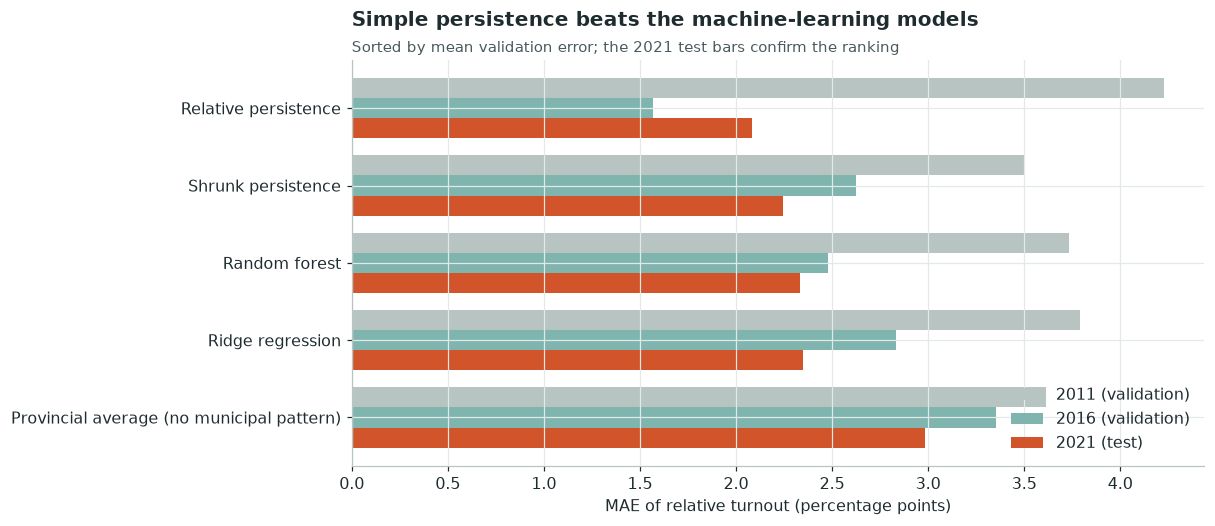

In [6]:
order = rel_table.index.tolist()
fig, ax = plt.subplots(figsize=(10, 4.8))
w = .26
for k, (y, col) in enumerate([(2011, "#B8C4C2"), (2016, C.TEAL_LIGHT), (2021, C.ALOE)]):
    vals = rel_table.loc[order, y]
    ax.barh(np.arange(len(order)) + (k - 1) * w, vals, height=w, color=col,
            label=f"{y} ({'test' if y == 2021 else 'validation'})")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlabel("MAE of relative turnout (percentage points)"); ax.legend(loc="lower right")
ax.set_title("Simple persistence beats the machine-learning models", pad=22)
subtitle(ax, "Sorted by mean validation error; the 2021 test bars confirm the ranking")
save(fig, "relative_model_comparison", "phase4"); plt.show()

**Interpretation.** Relative persistence has the lowest mean validation error and also the lowest 2021 test error (about 2.08 points). The 2011 fold is hard for every method because the 2006→2011 pattern was itself unstable (Notebook 03), but from 2011 onward a municipality's position carries over strongly. Ridge regression and random forests learn from too few elections to improve on this, which is an important result rather than a failure: complexity is not rewarded unless it generalises.

## 4. From relative position back to full turnout

To predict actual turnout, a provincial level must be assumed. Two simple rules are possible before an election: keep the previous level, or add the average historical change.

,TestYear,Role,LevelMethod,AssumedLevel,ActualLevel,MAE,RMSE,Bias,r
2,2011,validation,Previous level,57.19,58.03,4.15,5.04,-0.85,0.27
3,2011,validation,Average level change,58.07,58.03,4.23,4.97,0.04,0.27
12,2016,validation,Previous level,58.03,56.23,2.49,3.21,1.80,0.83
13,2016,validation,Average level change,58.90,56.23,3.26,3.76,2.67,0.83
22,2021,test,Previous level,56.23,48.03,8.20,8.66,8.20,0.77
23,2021,test,Average level change,56.20,48.03,8.18,8.64,8.18,0.77


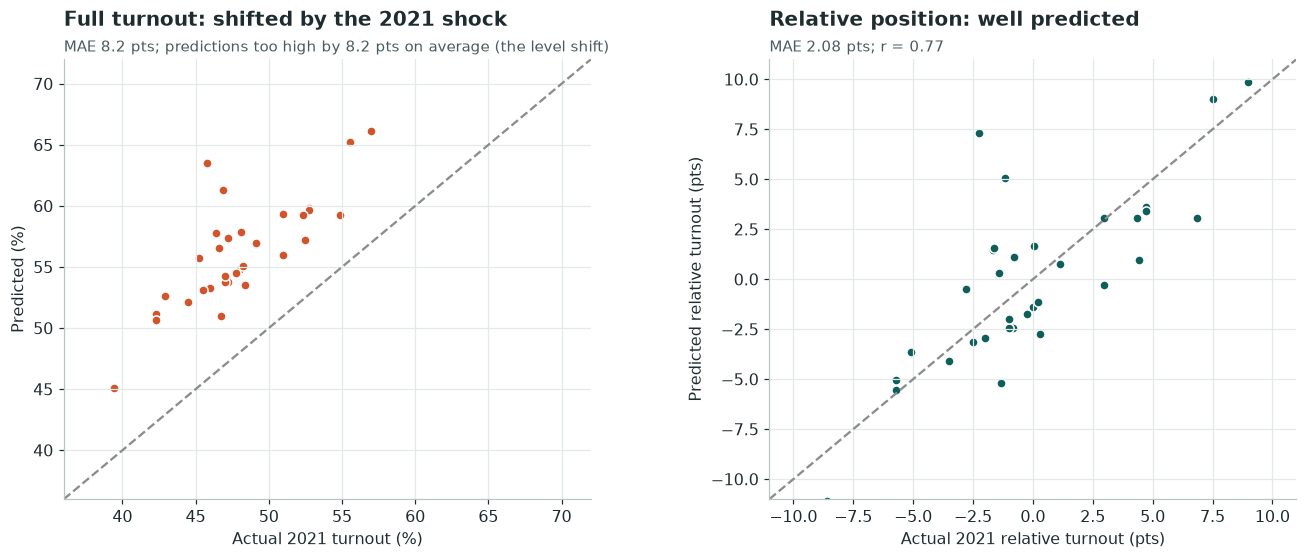

In [7]:
full_sel = full[full["RelativeModel"] == selected][["TestYear", "Role", "LevelMethod", "AssumedLevel", "ActualLevel", "MAE", "RMSE", "Bias", "r"]]
display(full_sel.round(3))

p21 = preds[preds["Year"] == 2021].copy()
p21["Pred"] = p21[f"Full|{selected}"]
lvl_err = full_sel.query("TestYear == 2021 and LevelMethod == 'Previous level'")
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
ax.scatter(p21["Turnout_%"], p21["Pred"], color=C.ALOE, s=36, edgecolor="white")
lim = [36, 72]; ax.plot(lim, lim, ls="--", color=C.GREY)
ax.set(xlim=lim, ylim=lim, xlabel="Actual 2021 turnout (%)", ylabel="Predicted (%)")
ax.set_title("Full turnout: shifted by the 2021 shock", pad=22)
subtitle(ax, f"MAE {lvl_err['MAE'].iloc[0]:.1f} pts; predictions too high by {lvl_err['Bias'].iloc[0]:.1f} pts on average (the level shift)")
ax = axes[1]
ax.scatter(p21["RelativeTurnout_pts"], p21[f"Rel|{selected}"], color=C.TEAL, s=36, edgecolor="white")
lim = [-11, 11]; ax.plot(lim, lim, ls="--", color=C.GREY)
ax.set(xlim=lim, ylim=lim, xlabel="Actual 2021 relative turnout (pts)", ylabel="Predicted relative turnout (pts)")
m21 = rel.query("TestYear == 2021 and Model == @selected").iloc[0]
ax.set_title("Relative position: well predicted", pad=22)
subtitle(ax, f"MAE {m21['MAE']:.2f} pts; r = {m21['r']:.2f}")
fig.tight_layout(); save(fig, "backtest_2021_actual_vs_predicted", "phase4"); plt.show()

**Interpretation.** In the left panel the points lie parallel to the diagonal but about 8 points below it: the model ranked municipalities correctly, but every municipality fell. Once the provincial level is removed (right panel), predictions sit close to the diagonal. This is the central modelling result of the project:

> **Where a municipality sits relative to the province is predictable to within about 2 points. How high the whole province goes is not predictable from five elections of municipal data.**

### How this relates to the earlier prototype's result

The prototype reported an "Average Change Baseline" with 2021 MAE 7.725 as its selected turnout model. That figure is the *full-turnout* error, dominated by the same level shock, and the method was chosen by comparing errors on 2021 itself. Under the design here, every level rule gives about 8.2 points on 2021, and the meaningful, validated quantity is the relative error of about 2.1 points.

## 5. Does Census information add anything?

Census 2011 is the newest census published before the 2016 and 2021 elections (as-known policy, Notebook 02). Because no earlier census is available in this dataset, a model with census inputs can only be trained on the 2016 target and tested on 2021, so it is a supplementary check, not a candidate for selection.

In [8]:
census_check = T.supplementary_census_check(master)
display(census_check.round(3))

,Inputs,TrainTarget,TestYear,MAE,RMSE,R2,Bias,r,n
0,Electoral history only,2016,2021,1.90,2.47,5.99e-01,-0.41,0.78,33
1,Electoral history + Census 2011,2016,2021,2.10,2.68,5.29e-01,-0.11,0.73,33
2,Census 2011 only,2016,2021,3.16,3.90,-1.00e-03,-0.00,0.26,33
3,Relative persistence (reference),2016,2021,2.08,2.78,4.91e-01,-0.00,0.77,33


**Interpretation.** Adding under-15 share, piped water and matric (as known in 2011) makes the ridge model slightly *worse* (2.10 against 1.90 points), and census variables alone predict relative turnout poorly (3.16). Together with Notebook 03 this gives a consistent picture: demographic context is *associated* with turnout differences, but that information is already reflected in a municipality's past turnout, so it adds little *forecasting* value.

**A disclosed observation.** In this check, a ridge model trained only on the 2016 transition scored 1.90 on 2021, slightly better than persistence (2.08). Adopting it now would mean choosing a method because of its 2021 score, which is exactly the selection-on-test error this design avoids, so the pre-declared choice stands. It does suggest a sensible extension for future work: training only on post-2011 transitions, when the relative pattern became stable.

## 6. Error scale carried into the 2026 scenarios

In [9]:
band = T.error_band(preds, selected, q=0.8)
band_table = pd.DataFrame([
    {"Quantity": "Selected relative model", "Value": selected},
    {"Quantity": "2021 test MAE, relative (pts)", "Value": round(m21["MAE"], 3)},
    {"Quantity": "MAE across all three folds, relative (pts)", "Value": round(band["mae_all_folds"], 3)},
    {"Quantity": "80% of historical absolute errors below (pts)", "Value": round(band["abs_error_quantile"], 3)},
])
display(band_table)
print("The 80% error scale is used as the municipal band in Notebook 06. It covers the municipal pattern only;")
print("uncertainty about the provincial level is shown separately through named scenarios.")

,Quantity,Value
0,Selected relative model,Relative persistence
1,"2021 test MAE, relative (pts)",2.08
2,"MAE across all three folds, relative (pts)",2.63
3,80% of historical absolute errors below (pts),3.79


The 80% error scale is used as the municipal band in Notebook 06. It covers the municipal pattern only;
uncertainty about the provincial level is shown separately through named scenarios.


In [10]:
out = C.DIRS["phase4"]
methodology = pd.DataFrame([
    ["Target", "Municipal turnout = provincial level + relative position"],
    ["Modelled component", "Relative position (points above/below provincial mean)"],
    ["Validation", "Rolling origin: folds 2011 and 2016 validation, 2021 test"],
    ["Selection rule", "Lowest mean validation MAE; decided before inspecting 2021"],
    ["Selected model", selected],
    ["Predictors", ", ".join(T.FEATURES) + " (all from the previous election)"],
    ["Leakage controls", "No same-election outcomes; no 2022 census in any backtest; no random splits"],
    ["Provincial level", "Not validated as forecastable; treated as a scenario assumption"],
], columns=["Item", "Value"])
files = {"turnout_relative_scores.csv": rel, "turnout_full_scores.csv": full,
         "turnout_backtest_predictions.csv": preds, "turnout_model_selection.csv": selection,
         "turnout_census_check.csv": census_check, "turnout_error_band.csv": band_table.astype(str),
         "phase4_methodology.csv": methodology}
for name, df in files.items():
    df.to_csv(out / name, index=False); print(f"Saved {name:40s} {len(df):4d} rows")
assert selected == "Relative persistence", "Selection changed: update the narrative in notebooks 04-06 and the docs"

Saved turnout_relative_scores.csv                15 rows
Saved turnout_full_scores.csv                    30 rows
Saved turnout_backtest_predictions.csv           99 rows
Saved turnout_model_selection.csv                 5 rows
Saved turnout_census_check.csv                    4 rows
Saved turnout_error_band.csv                      4 rows
Saved phase4_methodology.csv                      8 rows


## Summary

- Rolling-origin validation selected **relative persistence** without reference to 2021; it also has the lowest 2021 test error for relative turnout (about **2.08 points**, r ≈ 0.77).
- No method could anticipate the **−8.2-point** provincial shift in 2021; full-turnout error was about 8.2 points for every method.
- More complex models and Census inputs did not improve the forecast.

**Implication for 2026:** municipal turnout = *(assumed provincial level)* + *(municipality's 2021 relative position)*, with the provincial level presented as explicit scenarios.

**Limitations.** Three folds of 32–33 municipalities each; the relative pattern was unstable before 2011; MAE-based bands are empirical error scales, not probabilistic confidence intervals.

## References

Citations were compiled by the team; verify page/URL details before final submission.

- Hyndman, R.J. & Athanasopoulos, G. (2021). Forecasting: Principles and Practice, 3rd ed., ch. 5.10 (time-series cross-validation). https://otexts.com/fpp3/
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. JMLR 12, 2825-2830.
- Electoral Commission of South Africa (IEC). Municipal (Local Government) Election results, detailed downloads 2000, 2006, 2011, 2016, 2021. https://results.elections.org.za/home/downloads/me-results
- Statistics South Africa. Census 2011 and Census 2022 (https://census.statssa.gov.za). Note: the upstream tables behind data/processed/demographics/clean_census.csv are not recorded in the repository; see docs/DATA_SOURCES.md.

In [11]:
# Software used in this notebook (versions recorded for reproducibility)
import platform
from importlib.metadata import version, PackageNotFoundError
rows = [("python", platform.python_version())]
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'statsmodels', 'shapely', 'xlrd', 'nbformat']:
    try:
        rows.append((pkg, version(pkg)))
    except PackageNotFoundError:
        rows.append((pkg, "not installed"))
display(pd.DataFrame(rows, columns=["Package", "Version"]))

,Package,Version
0,python,3.13.15
1,pandas,3.0.6
2,numpy,2.5.3
3,matplotlib,3.11.2
4,scikit-learn,1.9.1
5,statsmodels,0.15.0
6,shapely,2.1.2
7,xlrd,2.0.2
8,nbformat,5.11.1
